# **Project Summary -**


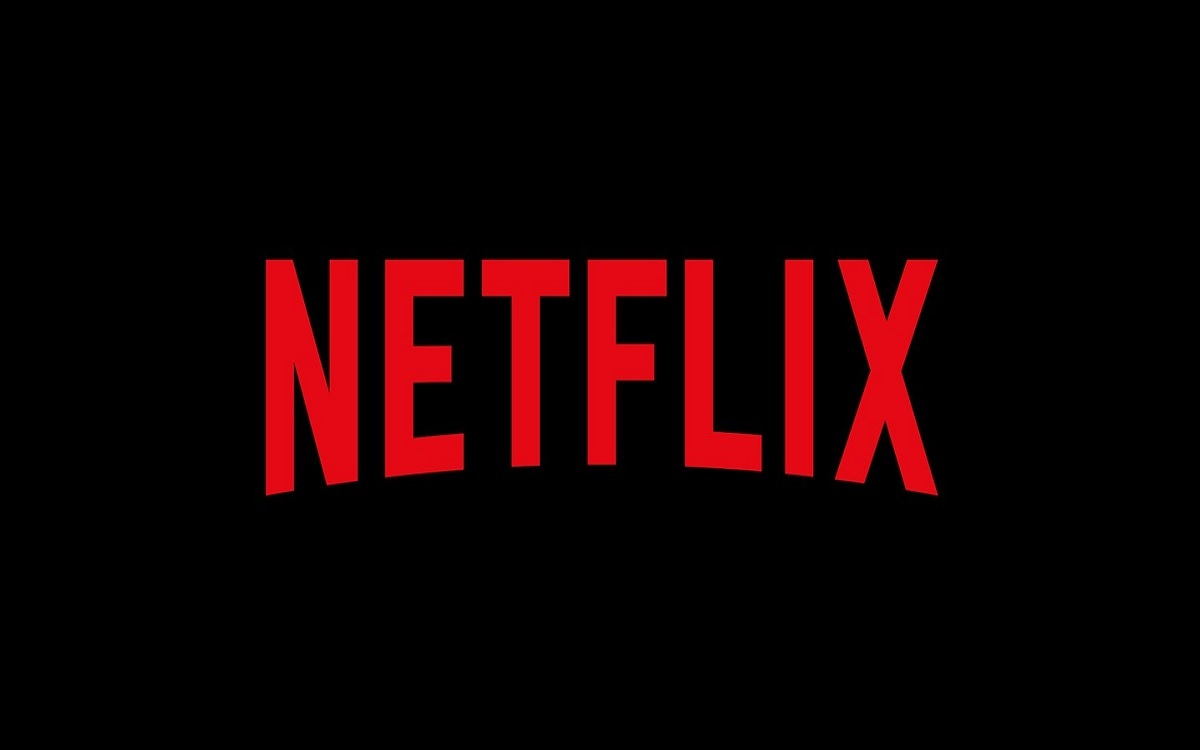
---



#**GITHUB**

https://github.com/amit-singh-tech/Netflix-Movies-and-TV-Shows-Clustering/tree/main

**Project Name**    -Netflix Movies and TV Shows Clustering



##### **Project Type**    - Unsupervised Machine Learning
#####

# **Project Summary -**

Netflix is an American subscription video on-demand over-the-top streaming service. The service primarily distributes original and acquired films and television shows from various genres, and it is available internationally in multiple languages.

Get ready to unlock hidden potential! This project meticulously addresses data quality issues, transforming raw information into a powerful resource.

This project harnesses machine learning to group Netflix's vast library of 7,000+ movies and shows by content, helping users discover hidden gems and navigate the platform effortlessly.

To gain insights into the diverse content offered by Netflix, we are going to analyze the dataset containing details about movies and TV shows. We will employee descriptive statistics to understand the distribution of key variables and create visualizations like scatterplots, histograms, line charts, heatmaps etc to explore relationships between them.

This multi-faceted approach will help us uncover valuable patterns and trends within the dataset. Moreover we will identify the key anamolies and try to work upon it.

A concluding statement will not only summarize our findings but also empower audiences to derive value and fuel their own projects with these actionable insights.

**Project Name**    -Netflix Movies and TV Shows Clustering



##### **Project Type**    - Unsupervised Machine Learning
#####

# **Problem Statement**


The objective of this undertaking is to examine the collection of movies and TV shows on Netflix, sourced from the third-party search engine Flixable, and categorize them into meaningful clusters. This effort aims to improve user satisfaction and reduce subscriber attrition for Netflix, the leading online streaming service provider globally, with a subscriber base exceeding 220 million as of the second quarter of 2022. By delving into the dataset, encompassing content available up to 2019, we intend to reveal fresh perspectives and patterns in the swiftly expanding domain of streaming entertainment.

The dataset encompasses TV shows and movies accessible on Netflix up until 2019, sourced from the third-party Netflix search engine, Flixable. In 2018, an intriguing report from Flixable highlighted a remarkable trend: the count of TV shows on Netflix had nearly tripled since 2010. During the same period, the collection of movies had diminished by over 2,000 titles, while TV show availability had experienced a nearly threefold increase. Exploring this dataset promises to reveal a wealth of additional insights awaiting discovery.

Furthermore, the potential for enriching this dataset by integrating it with external data sources like IMDB ratings

# **General Guidelines** : -  

1.   Well-structured, formatted, and commented code is required.
2.   Exception Handling, Production Grade Code & Deployment Ready Code will be a plus. Those students will be awarded some additional credits.
     
     The additional credits will have advantages over other students during Star Student selection.
       
             [ Note: - Deployment Ready Code is defined as, the whole .ipynb notebook should be executable in one go
                       without a single error logged. ]

3.   Each and every logic should have proper comments.
4. You may add as many number of charts you want. Make Sure for each and every chart the following format should be answered.
        

```
# Chart visualization code
```
            

*   Why did you pick the specific chart?
*   What is/are the insight(s) found from the chart?
* Will the gained insights help creating a positive business impact?
Are there any insights that lead to negative growth? Justify with specific reason.

5. You have to create at least 15 logical & meaningful charts having important insights.


[ Hints : - Do the Vizualization in  a structured way while following "UBM" Rule.

U - Univariate Analysis,

B - Bivariate Analysis (Numerical - Categorical, Numerical - Numerical, Categorical - Categorical)

M - Multivariate Analysis
 ]





6. You may add more ml algorithms for model creation. Make sure for each and every algorithm, the following format should be answered.


*   Explain the ML Model used and it's performance using Evaluation metric Score Chart.


*   Cross- Validation & Hyperparameter Tuning

*   Have you seen any improvement? Note down the improvement with updates Evaluation metric Score Chart.

*   Explain each evaluation metric's indication towards business and the business impact pf the ML model used.




















# ***Let's Begin !***

## ***1. Know Your Data***

### Import Libraries

In [ ]:

from google.colab import drive
drive.mount('/content/drive')

In [ ]:
# importing  libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

# Importing wordcloud library forcreating word clouds

from wordcloud import WordCloud, STOPWORDS
# Below libraries are used for text data prerocessing

import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')
import string
string.punctuation
from nltk.stem.snowball import SnowballStemmer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA

# library used for Clusters impelementation
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.cluster import AgglomerativeClustering
import scipy.cluster.hierarchy as sch


# library used for building recommandation system
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

# Importing Warnings library. it Would help to throw away warnings caused.

import warnings
warnings.filterwarnings('ignore')


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

### Dataset Loading

In [ ]:
df = pd.read_csv("/content/NETFLIX MOVIES AND TV SHOWS CLUSTERING.csv")
df

### Dataset Rows & Columns count

In [ ]:
# top 5 rows
df.head()

In [ ]:
# last 5 rows
df.tail()

# **Size of dataset**


In [ ]:
# rows and column count
print(f"Number of rows and columns : {df.shape} ")

#### Unique Values

In [ ]:
# unique value in each column
df.nunique()



#### Dataset **Information**

In [ ]:
# information of dataset
df.info()

# **Duplicate Values**


In [ ]:
# checking weather our data contain duplicate
df.duplicated().sum()

# **Missing Values/Null values**

In [ ]:
# missing values / null values count
df.isna().sum()

In [ ]:
# percentage of missing values
round(df.isna().sum()/len(df)*100,2)

In [ ]:
# checking null value by using heatmap
plt.figure(figsize = (8,5))
sns.heatmap(df.isnull(),cbar = False)

<> Nan valuespresent in the director,cast,country,date_added and rating column.

<> All the data that we have is related to each specific movie.So we can't impute any null values with using any method . Also we don't want to loose any data since data size is small for that reason we impute nan values with empty stings in below procedure after analyzing each columns.



# **Attributes Name**

In [ ]:
# Dataset column
df.columns

# **Statical Summary**


In [ ]:
df.describe(include='all').transpose()

# **Counting unique values**

In [ ]:
# check unique values for each variable
for i in df.columns:
  print(f"number of unique {i} column: {df[i].nunique()} \ n{df[i].unique()}")
  print('='*150)

<> After analyzing datasets we are more focusing towards 'type','title','director','cast','country','rating , 'listed_in' and these columns carrying a lots of information.

<> We are building our model on top of these features where those features are used to create one clusters column to implement K-means ,hierercial clustering and building conjtent based recommendations systems as well.

# **EDA**

Explaratory data analysis(EDA) is the very first state before you can perform any changes to the dataset or devlop a statical model to answers business problems. In other word the process of EDA contains summarizing,visualizing and getting deeply acquainated with the important trents of datasets.

# **Type Column**

In [ ]:
# number of unique values
df['type'].nunique()

In [ ]:
fig,ax = plt.subplots(1,2, figsize=(14,5))

# coutplot
graph = sns.countplot(x=df['type'], ax=ax[0])
graph.set_title('Values Count', size=18)
# adding value count on the top of bar
for p in graph.patches:  #adding value count on the top of bar
   graph.annotate(format(p.get_height(), '.0f'), (p.get_x(), p.get_height()))

# piechart
df['type'].value_counts().plot(kind='pie', autopct='%1.2f%%', ax=ax[1])
plt.title('Percentage Distribution', size=18)

plt.tight_layout()
plt.show()

# **Observations**


1 Greater number of count belong from movie class than Tv show class.

2 69% of data belong from Movie class and 31% of data belong from TV shows

# **Title Columns**

In [ ]:
df['title'].nunique()

In [ ]:

# text documents
text = " ".join(word for word in df['title'])

# create the word cloud
wordcloud = WordCloud(stopwords = STOPWORDS).generate(text)


# plot the word cloud
plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis("off")
plt.show()

**Obesrvation**: word like Christmas, Love, World, Man, Story are very comman word which are appear most of the time in movie title column.

#**Director column**

In [ ]:
print(f"Number of unique classes : {df.director.nunique()}")
print(f"Counting Null Values : {df.director.isna().sum()}")

In [ ]:
print(f"Number of TV Show directed by director is :{df[df['type']== 'TV Show']['director'].value_counts().sum()}")
print(f"Number of Movies Directed by director is  :{df[df['type']=='Movie']['director'].value_counts().sum()}")

In [ ]:
fig,ax = plt.subplots(1,2 , figsize = (15,5))

# top 10 director who directed TV show
show = df[df['type']== 'TV Show']['director'].value_counts()[:10].plot(kind = 'barh' , ax = ax[0])
show.set_title('top 10 director who directed TV Show', size=15)

# top 10 director who directed Movies
movie = df[df['type']=='Movie']['director'].value_counts()[:10].plot(kind = 'barh',ax = ax[1])
movie.set_title('top 10 director who directed Movies')


#**Obesrvation:**

Alstair Fothergill directed highest shows in datalist which is 3.


Raul Campos and Jan Suter together have directed 18 movies, higher than anyone in the dataset.

#**Cast column**

In [ ]:

# seperating actor from cast column
cast = df['cast'].str.split(',',expand = True).stack().reset_index(level = 1 , drop = True)

# top actors name who play highest role in movie/show.
cast.value_counts()


In [ ]:
print(f"Number of TV Show actors : {len(df[df['type']=='TV Show']['cast'].str.split(',', expand  = True).stack().reset_index(level = 1 , drop = True).value_counts())}")

print(f"Number of actors of movies : {len(df[df['type']=='Movie']['cast'].str.split(',', expand =  True).stack().reset_index(level = 1 , drop = True).value_counts())}")


In [ ]:

fig,ax = plt.subplots(1,2, figsize=(14,5))

# seperating TV shows actor from cast column
top_TVShows_actors = df[df['type'] == 'TV Show']['cast'].str.split(',' , expand  = True).stack().reset_index(level = 1 , drop = True)
colors = ['skyblue', 'salmon', 'lightgreen', 'gold', 'orchid', 'lightcoral', 'deepskyblue', 'mediumseagreen', 'lightsteelblue', 'khaki']

# plotting actor who appered highest number of TV Show
a = top_TVShows_actors.value_counts().head(10).plot(kind = 'barh' ,color = colors, ax = ax[0])
a.set_title('Top 10 TVshows actor', size=15)

# seperating movie actor from cast column
top_Movie_actors = df[df['type']=='Movie']['cast'].str.split(',' , expand = True).stack().reset_index(level = 1 , drop =True)

# plotting actor who appered highest number of Movie
b = top_Movie_actors.value_counts().head(10).plot(kind = 'barh' , color = colors , ax = ax[1])
b.set_title('top 10 Movie actor', size=15)


plt.tight_layout()
plt.show()

#**Observations**



Anupam Kher, Shahrukh Khan, Om Puri play highest number of role in the movies.


Takahiro Sakurai, Yuki Kaji, Daisuke Ono play highest role in the TV shows.

#**Country Column**

In [ ]:
df['country'].nunique()

In [ ]:


fig,ax = plt.subplots(1,2, figsize=(18,6))
plt.suptitle('Top 10 country with the highest number of movie/shows', weight='bold', size=15, y=1.01)

# univariate analysis

df['country'].value_counts().nlargest(10).plot(kind='barh', ax=ax[0]) #sns.countplot(x="country", data=df, order=df['country'].value_counts().index[0:10], ax=ax[0])

# bivariate analysis

graph = sns.countplot(x="country", data=df, hue='type', order=df['country'].value_counts().index[0:10], ax=ax[1])
plt.xticks(rotation=90)
for p in graph.patches:  #adding value count on the top of bar
   graph.annotate(format(p.get_height(), '.0f'), (p.get_x(), p.get_height()))



plt.tight_layout()
plt.show()


**Observation** : The highest number of movies / TV shows were based out of the US, followed by India and UK.



In [ ]:

# % share of movies / tv shows by top 10 countries
round(df['country'].value_counts().nlargest(10).sum()/len(df)*100,2)

The top 10 countries together account for about 63% of all movies and TV shows in the dataset.

#**Release_Year column**

In [ ]:

# number of unique values
df['release_year'].nunique()

In [ ]:

print(f'The oldest Record of TV/Movie show is : {df.release_year.min()}')

print(f'The Latest Record of TV/Movie show is : {df.release_year.max()}')

In [ ]:

fig,ax = plt.subplots(1,2,figsize = (18,6))

# Univariate analysis
hist = sns.histplot(df['release_year'], ax = ax[0])
hist.set_title('distribution by released year',size = 15)

# Bivariate analysis
count = sns.countplot(x = 'release_year' ,hue = 'type', data = df ,order = df['release_year'].value_counts().index[:15],ax = ax[1])
count.set_title('movie/shows release in top 15 year', size=15)

for p in count.patches:
  count.annotate(format(p.get_height(), '0.0f'),
                   (p.get_x() + p.get_width() / 2., p.get_height()),
                   ha='center', va='center',
                   xytext=(0, 9),
                   textcoords='offset points')

#***Observations**

Netflix has greater number of new movies / TV shows than the old ones.

Highest number of movie/shows are relesed in netflix in between 2015-2020 and highest number of count belong from 2018 year.

#**Rating columns**

In [ ]:

# Number of unique values in Rating column

df.rating.nunique()

In [ ]:

fig,ax = plt.subplots(1,2, figsize=(18,6))
plt.suptitle('Top 10 rating given for movie and shows', weight='bold', size=15, y=1.01)

# univariate analysis
df.rating.value_counts()[:10].plot(kind = 'barh' , ax = ax[0])

# bivariate analysis
graph = sns.countplot(x = 'rating' , data = df ,hue = 'type',order = df['rating'].value_counts().index[:15],ax = ax[1] )
plt.xticks(rotation=90)

for p in graph.patches:
  graph.annotate(format(p.get_height(),'0.0f'),(p.get_x(),p.get_height()))

plt.tight_layout()
plt.show()


#**Obesrvation**

most of the movie and tv shows have rating of TV-MA (Mature Audiance) then followed by TV-14 (younger audiance).


Highest number of rating given for the movies as compared to TV shows it is pretty obivious because of gighet number of category belong from mvoie class as we can seen earlier in type column.

#**Listed_In column (Gener)**

In [ ]:
df.head()

In [ ]:
# seperating genre from listed_in columns for analysis purpose

genres = df['listed_in'].str.split(',' , expand = True).stack().reset_index(level = 1 , drop = True)
genres.head()

# top 10 genre in listed movie/show
genres = genres.value_counts().reset_index().rename(columns = {'index': 'genres' , 0:'count'})
genres[:10]

In [ ]:

# number of genres present in dataset
len(genres)


In [ ]:

# plotting graph
plt.figure(figsize=(16,5))
graph = sns.barplot(x='genres', y='count', data=genres)
graph.set_title('Top genres present in netflix', size=20)
plt.xticks(rotation=90)

#adding value count on the top of bar
for p in graph.patches:
   graph.annotate(format(p.get_height(), '.0f'), (p.get_x(), p.get_height()))

plt.show()

#**Obesrvation :**

Highest number of genre belong from International movies, Dramas, Comedies respectively.


Least number of genre belong from Classic & cult TV, TV Thriller, Stand-Up comedy and Talk show.

#** Description**

In [ ]:
# Text Documents
text = ''.join(word for word in df['description'])

# create the word cloud
wordcloud = WordCloud(stopwords = STOPWORDS).generate(text)

# plot the word cloud
plt.imshow(wordcloud,interpolation = 'bilinear')
plt.axis('off')
plt.show()

**Observation** : Most of the comman words present in description column are family, find, life, love, new, world, friend.

#**Data Cleaning**

Data cleaning is the process of modifying data to fit the criteria for a specific problem, and you'll have no idea what you might want to change about a data set until you know what's in it.

After EDA we are perfoming data cleaning process.

In [ ]:

df.duplicated().sum()

We can see that we don't have any duplicate values in our data set

#**Handling Missing Values**

In [ ]:
# Ploting Missing values

import missingno as msno
msno.bar(df,figsize = (10,5) , fontsize = 12)


In [ ]:
# Missing Data %

round(df.isna().sum() / len(df)*100 , 2).sort_values(ascending = False)

The missing values in the director, cast, and country attributes can be replaced with 'empty string'.



Small amount of null value percentage present in rating and date_added column, if we drop these nan values it will not affect that much while building the model. So, we simply drop the nan value present in rating and date_added columns.

In [ ]:
# Handling Missing Values & Missing Value Imputation

df[['director' , 'cast' , 'country']] = df[['director' , 'cast' , 'country']].fillna('')
df.dropna(axis = 0 , inplace = True)


In [ ]:
# checking for null values after treating them.
df.isna().sum()

Our Data is now free from NA Values

#**Handling Outlier**

In [ ]:

# boxplot for outlier detection
sns.boxplot(data  = df)

Since, the almost all of the data present in textual format except release year.


The data that we need to create cluster/building model are present in textual foramat. So, there is no need to perform handling outlier.

#**Textual Data Preprocessing**

**Modeling Approach**

Modeling Approach

Select the attributes based on which you want to cluster the shows


Text preprocessing: Remove all stopwords and punctuation marks, convert all textual data to lowercase.


Stemming to generate a meaningful word out of corpus of words.


Tokenization of corpus and Word vectorization
Dimensionality reduction


Use different algorithms to cluster the movies, obtain the optimal number of clusters using different techniques
Build optimal number of clusters and visualize the contents of each cluster using wordclouds.

#**Clustering Attributes**


We will cluster the movie/shows on Netflix based on the following attributes:

Director

Cast

Country

Rating

Listed in (genres)

Description

In [ ]:
# creating tags column using all text column which one is used for model building purpose.
df['tags'] = df['description'] + df['listed_in'] + df['rating'] + df['cast'] + df['country'] + df['director']

We have successfully added all the necessary data into a single column.

In [ ]:
df.tags[0]

#**Removing Stopwords and Lower Casing.**

Removing stop words and lowercasing words are common pre-processing steps in natural language processing (NLP) tasks.

Stop words are words that are commonly used in a language but do not convey much meaning on their own, such as "a," "an," "the," and "is." These words can add noise to the data and can sometimes affect the performance of NLP models, so they are often removed as a pre-processing step.

Lowercasing words is the process of converting all the words in a text to lowercase. This is a common pre-processing step in NLP tasks, as it can be useful for a few reasons:

Case differences can be ignored: By lowercasing the words, you can treat words with different capitalization as the same word, which can be useful in tasks such as information retrieval or text classification where case differences are not important.
Vocabulary size is reduced: Lowercasing the words can also reduce the size of the vocabulary, which can make it easier to work with larger texts or texts in languages with a high number of inflected forms.

In [ ]:

import nltk
from nltk.corpus import stopwords
import numpy as np

# download the stop words list if it is not already downloaded
nltk.download('stopwords')

# create a set of English stop words
stop_words = stopwords.words('english')

# displaying stopwords
np.array(stop_words)

In [ ]:

def stopwords(text):


  '''a function for removing the stopword and lowercase the each word'''
  text = [word.lower() for word in text.split() if word.lower() not in stop_words]
  # joining the list of words with space separator
  return " ".join(text)

In [ ]:

# applying stopwords function.
df['tags'] = df['tags'].apply(stopwords)

In [ ]:

df.tags[0]

We have successfully removed all the stopwords and converted the corpus to lowercase.

#** Removing Punctuations**

Removing punctuation is a common pre-processing step in natural language processing (NLP) tasks. Punctuation marks like periods, commas, and exclamation points can add noise to the data and can sometimes be treated as separate tokens, which can affect the performance of NLP models.

In [ ]:

# function to remove punctuations
def removing_punctuation(text):
  '''a function for removing punctuation'''
  import string
  # replacing the punctuations with no space, which in effect deletes the punctuation marks.
  translator  = str.maketrans('','',string.punctuation)
  # return the text stripped of punctuation marks
  return text.translate(translator)


In [ ]:

# applying remove_punctuation function
df['tags'] = df['tags'].apply(removing_punctuation)

In [ ]:

df.tags[0]

We have successfully remove all the punctuation marks from the corpus.

#**Stemming**

Used SnowballStemmer to generate a meaningful word out of corpus of words.

Stemming is the process of reducing a word to its base or root form. This is a common pre-processing step in natural language processing (NLP) tasks, as it allows you to treat different inflected forms of a word as the same word, which can be useful for tasks like information retrieval or text classification.

For example, the words "run," "runs," "ran," and "running" are all different inflected forms of the same word "run," and a stemmer can reduce them all to the base form "run."

In [ ]:

from nltk.stem.snowball import SnowballStemmer

# create an object of stemming function
stemmer = SnowballStemmer('english')

def stemming(text):
  '''a function which stems each word in the given text'''
  text = [stemmer.stem(word) for word in text.split()]
  return ''.join(text)

In [ ]:

# Applying stemming function to tag column
df['tags'] = df['tags'].apply(stemming)
df['tags'].head()

In [ ]:

df.tags[0]

We are done with stemming the corpus.

#** Text Vectorization**

Word/Text vectorization is the process of representing words as numerical vectors. This is important in NLP tasks because most machine learning models expect numerical input and cannot work with raw text data directly. Word vectorization allows you to input the words into a machine learning model in a way that preserve the meaning and context of the words. Word vectorization can also be used to measure the similarity between words using vector arithmetic.

We can vectorize the corpus using TFIDF vectorizer, where TFIDF stands for Term Frequency Inverse Document Frequency.

TF(t) = (Number of times term t appears in a document) / (Total number of terms in the document).

IDF(t) = log(total number of documents/Number of documents with term tin it)



In [ ]:

# creating the object of tfid vectorizer

tfidf = TfidfVectorizer(stop_words = 'english' , lowercase = False, max_features = 10000)

# fit the vectorizer using the text data
tfidf.fit(df['tags'])

# collect the vocabulary items used in the vectorizer
dictionary = tfidf.vocabulary_.items( )

In [ ]:

print(len(dictionary)) #number of independet features created from "tags" columns ---> max_features=10000

In [ ]:

# convert vector into array form for clustering
vector = tfidf.transform(df['tags']).toarray()

# summarize encoded vector
print(vector)
print(f'shape of the vector : {vector.shape}')
print(f'datatype : {type(vector)}')

#**Dimesionality Reduction**

We can use PCA (Principal component Analysis) to reduce the dimensionality of data.

Dimensionality reduction is the process of reducing the number of features or dimensions in a dataset while preserving as much information as possible. It is a common step in machine learning and data analysis, as high-dimensional datasets can be difficult to work with and can sometimes suffer from the curse of dimensionality.

In [ ]:
# using PCA to reduce dimensionality
pca = PCA(random_state = 42)
pca.fit(vector)

In [ ]:

# Explained variance for different number of components
plt.figure(figsize = (8,4))
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.title('PCA - cumulative explained variance vs number of components')
plt.xlabel('Number of Components')
plt.ylabel('cumulative explained variance')
plt.axhline(y = 0.8 , color = 'red' , linestyle = '--')
plt.axvline(x = 3000,color = 'green',linestyle = '--')
plt.show()

We find that 100% of the variance is explained by about ~7500 components.
Also, more than 80% of the variance is explained just by 3000 components.
Hence to simplify the model, and reduce dimensionality, we can take the top 3000 components, which will still be able to capture more than 80% of variance

In [ ]:

# reducing the dimensions to 3000 using pca

pca = PCA(n_components = 3000, random_state=42)
pca.fit(vector)


In [ ]:
# transformed features

X = pca.transform(vector)

# shape of transformed vectors
X.shape

#**Clusters implementation**

**K-Means Clustering**

K-means clustering is an unsupervised machine learning algorithm that is used to divide a dataset into a specified number of clusters. It is called "unsupervised" because the algorithm does not use any labeled examples to learn about the data. Instead, it relies on the inherent structure of the data to group the samples into clusters.

How It's Work?

The k-means algorithm works by first selecting k initial "centroids," or cluster centers, at random from the data.
Then, it assigns each sample in the dataset to the nearest centroid, based on some distance metric like Euclidean distance.
The algorithm then updates the centroids to be the mean of the samples in each cluster.
teratively repeats the process of reassigning samples to the nearest centroids and updating the centroids until convergence.
Visualizing the elbow curve and Silhouette score to decide on the optimal number of clusters for K-means clustering algorithm

In [ ]:

'''Elbow method to find the optimal value of k'''

# Initialize a list to store the sum of squared errors for each value of k
SSE = []

for k in range(1,16):
  # Initialize the k-means model with the current value of k
  kmeans = KMeans(n_clusters=k , init = 'k-means++' , random_state=42)
  # Fit the model to the data
  kmeans.fit(X)
  # Compute the sum of squared errors for the model
  SSE.append(kmeans.inertia_)

# Plot the values of SSE
plt.plot(range(1,16),SSE)
plt.title('The Elbow Method - KMeans clustering')
plt.xlabel('Number of clusters')
plt.ylabel('Sum of squared errors')
plt.show()



The sum of squared distance between each point and the centroid in a cluster decreases with the increase in the number of clusters.

In [ ]:
'''Silhouette score method to find the optimal value of k'''

# Initialize a list to store the silhouette score for each value of k
silhouette_avg = []

for k in range(2, 16):
  # Initialize the k-means model with the current value of k
  kmeans = KMeans(n_clusters=k, init='k-means++', random_state=42)
  # Fit the model to the data
  kmeans.fit(X)
  # Predict the cluster labels for each point in the data
  labels = kmeans.labels_
  # Compute the silhouette score for the model
  score = silhouette_score(X, labels)
  silhouette_avg.append(score)

# Plot the Silhouette analysis
plt.plot(range(2,16), silhouette_avg)
plt.xlabel('Number of clusters')
plt.ylabel('Silhouette score')
plt.title('Silhouette analysis For Optimal k - KMeans clustering')
plt.show()

The highest Silhouette score is obtained for 2 clusters

#**Building 2 clusters using the k-means clustering algorithm:**

In [ ]:
# Clustering the data into 5 clusters
kmeans = KMeans(n_clusters=2,init = 'k-means++' , random_state=42)
kmeans.fit(X)

In [ ]:

# Evaluation metrics - distortion, Silhouette score

kmeans_distortion = kmeans.inertia_
kmeans_silhouette_score = silhouette_score(X,kmeans.labels_)

print(kmeans_distortion,kmeans_silhouette_score)

In [ ]:

# Adding a kmeans cluster number attribute
df['kmeans_cluster'] = kmeans.labels_


In [ ]:
df.sample(2)[['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description', 'kmeans_cluster']]


In [ ]:

# Number of movies and tv shows in each cluster

plt.figure(figsize=(8,5))
graph = sns.countplot(x = 'kmeans_cluster' , data = df , hue = 'type')
plt.title('Number of movies and TV shows in each cluster - Kmeans Clustering')

# adding value count on the top of bar
for p in graph.patches:
   graph.annotate(format(p.get_height(), '.0f'), (p.get_x(), p.get_height()))


**Building wordclouds for different clusters in K-Means Clustering**

In [ ]:
def kmeans_wordcloud(cluster_number,column_name):

  '''function for Building a wordcloud for the movie/shows'''

  df_wordcloud = df[['kmeans_cluster' , column_name]].dropna()
  df_wordcloud = df_wordcloud[df_wordcloud['kmeans_cluster'] == cluster_number]

  # text documents
  text = ''.join(word for word in df_wordcloud[column_name])

  # create the word cloud
  wordcloud = WordCloud(stopwords = set(STOPWORDS) , background_color='white').generate(text)

  # Generate a word cloud image
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis("off")
  plt.show()

In [ ]:

for i in range(2):


  print(f'cluster{i}')
  kmeans_wordcloud(i,'description')

In [ ]:

for i in range(2):
  print(f'cluster{i}')
  kmeans_wordcloud(i,'cast')

**Word Cloud on "director" column for different cluster**

In [ ]:

for i in range(2):
  print(f'cluster{i}')
  kmeans_wordcloud(i , 'director')


**Word Cloud on "listed_in" (genre) col for different cluster**

In [ ]:
for i in range(2):
  print(f'cluster {i}')
  kmeans_wordcloud(i,'listed_in')

**Word Cloud on "country" column column for different cluster**

In [ ]:

for i in range(2):
  print(f'cluster {i}')
  kmeans_wordcloud(i,'country')

Word Cloud on "title" column column for different cluster

In [ ]:

for i in range(2):
  print(f'cluster {i}')
  kmeans_wordcloud(i,'title')

 # **Hierarchical clustering**


Building clusters using the Agglomerative (hierarchical) clustering algorithm.

Agglomerative hierarchical clustering is a method of clustering that is used to build a hierarchy of clusters. It is a bottom-up approach, where each sample is initially treated as a single-sample cluster and clusters are merged together as they are deemed similar.

How it's work?

The algorithm starts by calculating the distance between all pairs of samples and storing them in a distance matrix.
Then selects the two closest clusters and merges them into a single cluster.
Above process is repeated until all the samples are in the same cluster.
The resulting clusters form a tree-like structure called a dendrogram, which shows the relationships between the clusters at each level of the hierarchy.

Visualizing the dendrogram to decide on the optimal number of clusters for the agglomerative (hierarchical) clustering algorithm:

In [ ]:
# Building a dendogram to decide the number of clusters
import matplotlib.pyplot as plt
import scipy.cluster.hierarchy as shc

plt.figure(figsize=(10, 7))
dend = shc.dendrogram(shc.linkage(X, method='ward'))
plt.title('Dendrogram')
plt.xlabel('Netflix Shows')
plt.ylabel('Distance')
plt.axhline(y=4, color='r', linestyle='--')
plt.show()


In [ ]:

# Fitting hierarchical clustering model
hierarchical = AgglomerativeClustering(n_clusters=7 , affinity='euclidean' , linkage = 'ward')
hierarchical.fit_predict(X)

In [ ]:

# Adding a hierarchical cluster number attribute
df['hierarchical_cluster'] = hierarchical.labels_

In [ ]:

df.sample(5)[['type', 'title', 'director', 'cast', 'country', 'rating', 'listed_in', 'description', 'hierarchical_cluster']]

In [ ]:

# Number of movies and tv shows in each cluster
plt.figure(figsize = (10,5))
graph = sns.countplot(x = 'hierarchical_cluster' , data = df  , hue = 'type')
plt.title('Number of movies and tv shows in each cluster - Hierarchical Clustering')

# adding value count on the top of bar
for p in graph.patches:
   graph.annotate(format(p.get_height(), '.0f'), (p.get_x(), p.get_height()))


#**Building wordclouds for different clusters in hierarchical Clustering**

In [ ]:

def hierarchical_wordcloud(cluster_number , column_name):

  '''function for Building a wordcloud for the movie/shows'''
  df_wordcloud  = df[['hierarchical_cluster',column_name]].dropna()
  df_wordcloud = df_wordcloud[df_wordcloud['hierarchical_cluster']== cluster_number]

  # text documents
  text = " ".join(word for word in df_wordcloud[column_name])

  # create the word cloud
  wordcloud = WordCloud(stopwords = set(STOPWORDS) , background_color = 'white').generate(text)

  # Generate a word cloud image
  plt.imshow(wordcloud, interpolation='bilinear')
  plt.axis("off")
  plt.show()

In [ ]:

for i in range(7):
  print(f'cluster {i}')
  hierarchical_wordcloud(i,'title')

#**Word Cloud on "cast" column for different cluster**

In [ ]:

for i in range(7):
  print(f'cluster {i}')
  hierarchical_wordcloud(i,'cast')


#**Content Based Recommendation System**
Content-based recommendation systems recommend items to a user by using the similarity of items. This recommender system recommends products or items based on their description or features. It identifies the similarity between the products based on their descriptions.

It short notes which items a particular user likes and also the items that the users with behavior and likings like him/her likes, to recommend items to that user.

We can build a simple content based recommender system based on the similarity of the movie/shows.
If a person has watched a show on Netflix, the recommender system must be able to recommend a list of similar shows that s/he likes.
To get the similarity score of the shows, we can use cosine similarity.
The similarity between two vectors (A and B) is calculated by taking the dot product of the two vectors and dividing it by the magnitude value. We can simply say that the cosine similarity score of two vectors increases as the angle between them decreases.

In [ ]:

# veryfying index
df[['show_id', 'title', 'tags']]

As you can see above dataframe We successfully reset the index. Now dataset is ready to build content based recommandation system.

In [ ]:

# dropping show-id and index column
recomender_df.drop(columns=['index', 'show_id'], inplace=True)

In [ ]:
print(f"before reset index id for movie 'Zero' : {df[df['title'] == 'Zero'].index[0]}")  # index[0] --> to locate index position
print(f"after reset index id for movie 'Zero': {recomender_df[recomender_df['title'] == 'Zero'].index[0]}")

In [ ]:

# calculate cosine similarity
similarity = cosine_similarity(X)
similarity

**Function for list down top 10 recommended movie on the basis of cosine similarity score**

In [ ]:

def recommend(movie):
  '''
  This function list down top ten movies on the basis of similarity score for that perticular movie.
  '''
  print(f"If you liked '{movie}', you may also enjoy: \n")

  # find out index position
  index = recomender_df[recomender_df['title'] == movie].index[0]

  # sorting on the basis of simliarity score, In order to find out distaces from recommended one
  distances = sorted(list(enumerate(similarity[index])),reverse = True , key = lambda x:x[1])

  # listing top ten recommenaded movie
  for i in distances[1:11]:
        print(df.iloc[i[0]].title)

In [ ]:

recommend('Naruto')

 # **Which Evaluation metrics did you consider for a positive business impact and why?**


We have chosen Silhoutte Score over Distortion Score (also known as inertia or sum of squared distances) as evaluation metrics as it measures how well each data point in a cluster is separated from other clusters. It ranges from -1 to 1, with higher values indicating better cluster separation. A silhouette score close to 1 indicates that the data point is well-matched to its own cluster and poorly matched to neighboring clusters. A score close to 0 indicates that the data point is on or very close to the boundary between two clusters. A score close to -1 indicates that the data point is probably assigned to the wrong cluster.

The advantages of using silhouette score over distortion score are:

Silhouette score takes into account both the cohesion (how well data points within a cluster are similar) and separation (how well data points in different clusters are dissimilar) of the clusters, whereas distortion score only considers the compactness of each cluster.
Silhouette score is less sensitive to the shape of the clusters, while distortion score tends to favor spherical clusters, and in our case the clusters are not completely spherical.
Silhouette score provides more intuitive and interpretable results, as it assigns a score to each data point rather than just a single value for the entire clustering solution.



#**2. Which ML model did you choose from the above created models as your final prediction model and why?**
We have considered K-means as our final model, as we are getting the comparatevely high Silhoutte Score in K-means clustering and the resulted clusters are very well seperated from each others as have saw in the 3 dimensions.

Also in some of the situations K-means works more accurately then other clustering methods such as:

Speed: K-means is generally faster than hierarchical clustering, especially when dealing with large datasets, since it involves fewer calculations and iterations.

Ease of use: K-means is relatively straightforward to implement and interpret, as it requires only a few parameters (such as the number of clusters) and produces a clear partitioning of the data.

Scalability: K-means can easily handle datasets with a large number of variables or dimensions, whereas hierarchical clustering becomes computationally expensive as the number of data points and dimensions increase.

Independence of clusters: K-means produces non-overlapping clusters, whereas hierarchical clustering can produce overlapping clusters or clusters that are nested within each other, which may not be ideal for certain applications.

#**Conclusions**

In this project, we worked on a text clustering problem wherein we had to classify/group the Netflix shows into certain clusters such that the shows within a cluster are similar to each other and the shows in different clusters are dissimilar to each other.
The dataset contained about 7787 records, and 11 attributes.
We began by dealing with the dataset's missing values and doing exploratory data analysis (EDA).
It was found that Netflix hosts more movies than TV shows on its platform, and the total number of shows added on Netflix is growing exponentially. Also, majority of the shows were produced in the United States.
It was decided to cluster the data based on the attributes: director, cast, country, genre, rating and description. The values in these attributes were tokenized, preprocessed, and then vectorized using TFIDF vectorizer.
Through TFIDF Vectorization, we created a total of 10000 attributes.
We used Principal Component Analysis (PCA) to handle the curse of dimensionality. 3000 components were able to capture more than 80% of variance, and hence, the number of components were restricted to 3000.
We first built clusters using the K-Means Clustering algorithm, and the optimal number of clusters came out to be 5. This was obtained through the elbow method and Silhouette score analysis.
Then clusters were built using the Agglomerative clustering algorithm, and the optimal number of clusters came out to be 7. This was obtained after visualizing the dendrogram.
A content based recommender system was built using the similarity matrix obtained after using cosine similarity. This recommender system will make 10 recommendations to the user based on the type of show they watched.